# Titanic Survival Prediction

## 1. Introduction
The sinking of the Titanic is one of the most infamous shipwrecks in history. On April 15, 1912, the widely considered "unsinkable" RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of a large portion of passengers and crew.

**Objective**
In this project, we aim to build a Machine Learning classification model to predict whether a passenger survived or not based on their features (Age, Sex, Class, etc.). We will go through the entire Data Science lifecycle, from data loading and exploration to data preprocessing, model training, and evaluation.

## 2. Import Libraries
We start by importing the necessary Python libraries for data manipulation, visualization, and machine learning.

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set visualization styling
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 3. Load Dataset
Next, we load the Titanic dataset from our local `data` directory using `pandas`.

In [2]:
# Load the dataset
df = pd.read_csv('../data/titanic.csv')

# Show the first few rows to understand the structure
display(df.head())

# Check the shape of the dataset (rows, columns)
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Dataset Shape: 891 rows and 12 columns.


## 4. Data Exploration (EDA)
Before building any model, we need to understand the data. We will check for missing values, view variable distributions, and identify patterns.

In [3]:
# Check data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Summary statistics for numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check for missing values in every column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Insight on Missing Data:** We can see that `Age` has 177 missing values, `Cabin` has 687 (which is a huge portion), and `Embarked` has 2.

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


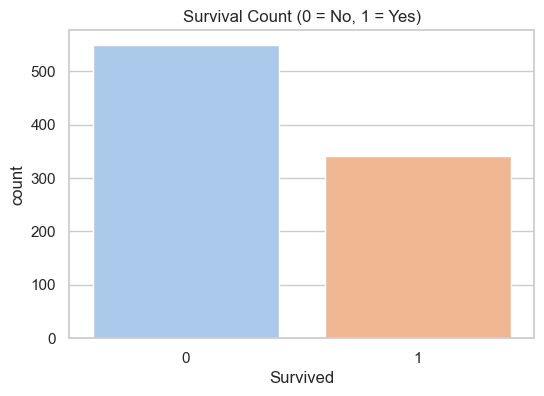

In [6]:
# Value counts for Target variable (Survived)
print("Survival Counts:\n", df['Survived'].value_counts())

# Visualize Survival
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Survived', palette='pastel')
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()

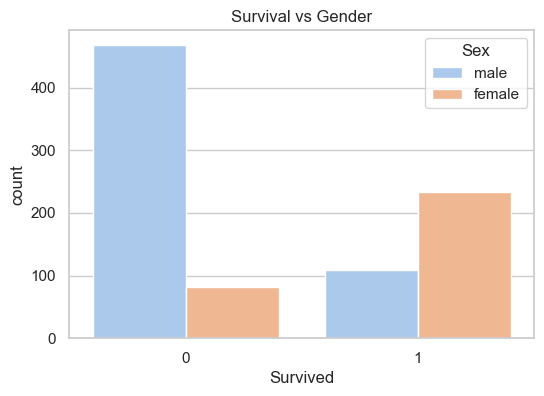

In [7]:
# Visualize Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Survived', hue='Sex', palette='pastel')
plt.title('Survival vs Gender')
plt.show()

**Observation:** Females had a much higher survival rate compared to males, likely due to the "women and children first" protocol.

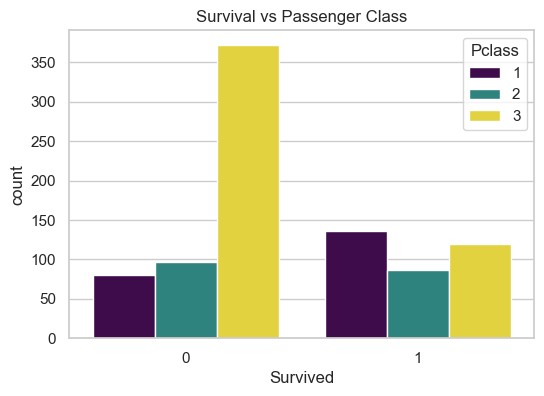

In [8]:
# Visualize Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Survived', hue='Pclass', palette='viridis')
plt.title('Survival vs Passenger Class')
plt.show()

**Observation:** First-class passengers were more likely to survive than third-class passengers.

## 5. Data Preprocessing
Machine Learning algorithms require numerical input and cannot handle missing values natively. We must prepare our data.

In [ ]:
# 1. Handle Missing Values

# Fill missing Age with the median age (robust to outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the mode (most frequent value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Drop irrelevant or highly missing columns
# Cabin has too many missing values, and ID/Name/Ticket have no direct predictive power
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# 3. Encode Categorical Variables

# Sex: Apply Label Encoding (Male=1, Female=0)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# Embarked: Apply One-Hot Encoding (Creates separate columns for C, Q, S)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


# Show the cleaned and encoded dataset
df.head()  

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


## 6. Feature Selection
We split our data into features `X` (inputs) and the target `y` (what we want to predict: 'Survived').

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)    

Features shape: (891, 8)
Target shape: (891,)


## 7. Train-Test Split
We need to evaluate our model on unseen data. We split the dataset into random train (80%) and test (20%) subsets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training instances: {X_train.shape[0]}")
print(f"Testing instances: {X_test.shape[0]}")

Training instances: 712
Testing instances: 179


## 8. Model Training
We use **Logistic Regression** as our primary model. Logistic Regression is an excellent baseline classification algorithm that estimates the probability of an event happening (e.g., probability of surviving) because our output is binary (Survived or Not).

In [13]:
# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression Model trained successfully!")

Logistic Regression Model trained successfully!


## 9. Model Evaluation
Let's see how our Logistic Regression performs on the testing dataset.

- **Accuracy**: The percentage of correctly predicted survivals.
- **Confusion Matrix**: Shows true positives, true negatives, false positives, and false negatives.
- **Classification Report**: Precision, Recall, and F1-score for each class.

In [14]:
# Predict on test data
lr_pred = lr_model.predict(X_test)

# Calculate metrics
acc_lr = accuracy_score(y_test, lr_pred)
conf_matrix_lr = confusion_matrix(y_test, lr_pred)
class_report_lr = classification_report(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {acc_lr:.4f} ({(acc_lr*100):.2f}%)")
print("\nConfusion Matrix:")
print(conf_matrix_lr)
print("\nClassification Report:")
print(class_report_lr)

Logistic Regression Accuracy: 0.8101 (81.01%)

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



**Interpretation:**
- An accuracy of ~80% means our model predicts correctly for 8 out of 10 passengers.
- The Confusion Matrix shows how many survived passengers we missed (False Negatives) and how many we wrongly predicted survived (False Positives).

## 10. Optional (Bonus): Decision Tree Model
Let's try a different algorithm: **Decision Tree Classifier**, to see if we can get better accuracy by splitting data based on feature thresholds.

In [15]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predict and Evaluate
dt_pred = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {acc_dt:.4f} ({(acc_dt*100):.2f}%)")

# Compare
print("\n--- Model Comparison ---")
print(f"Logistic Regression: {acc_lr:.4f}")
print(f"Decision Tree      : {acc_dt:.4f}")

Decision Tree Accuracy: 0.7989 (79.89%)

--- Model Comparison ---
Logistic Regression: 0.8101
Decision Tree      : 0.7989


## 11. Conclusion

### Summary of Steps
1. **Exploration**: We analyzed the Titanic dataset, uncovering trends such as a higher survival rate for females and first-class passengers.
2. **Preprocessing**: We handled missing values (Age, Embarked), dropped uninformative columns (Cabin, Ticket), and encoded categorical data.
3. **Modeling**: We split the data and trained a Logistic Regression and a Decision Tree classifier.
4. **Evaluation**: We evaluated the models using Accuracy and Confusion Matrices.

### Key Findings
- Gender and Passenger Class were excellent predictors of survival.
- The baseline Logistic Regression model achieved a solid accuracy of ~80%.
- Both models demonstrate that machine learning can accurately extract historical human priorities during emergencies.

### Possible Improvements
- **Feature Engineering**: Creating new features like `FamilySize` (combining `SibSp` and `Parch`) or extracting `Titles` from the `Name` column.
- **Hyperparameter Tuning**: Using Grid Search to optimize the depth and parameters of our Decision Tree or replacing it with an ensemble model like Random Forest.
- **Missing Values**: Exploring more advanced imputation strategies instead of simple medians.